# HPO Overview - Analysis

HPO is a directed Acyclic Graph (DAG), which acts as a hierarchical, multi-parent structure representing the relationships between phenotypic abnormalities.

- Directed: Edges have a specific direction (usually "is-a" relationship)
- Acyclic: There are no loops.
- Nodes & Relationship: Nodes are HPO terms and edges define hierarchical relations
- Multi-Parenting: Unlike a strict tree, a single HPO term can have multiple parent terms.

## 1. Importing Libs and Load HPO Ontology

In [13]:
from owlready2 import *
import matplotlib.pyplot as plt
from collections import Counter
import networkx as nx
from graphviz import Digraph


print("Loading HPO ontology...")
hpo = get_ontology("model/hp.owl").load()
print("Ontology loaded.")

Loading HPO ontology...
Ontology loaded.


## 2. Statistical Analysis
### Basic Counts

The Human Phenotype Ontology is a schema ontology, meaning it defines:

- concepts
- relationships
- metadata

but not actual patient data, which is why there are no individuals

In [15]:
classes = list(hpo.classes())
individuals = list(hpo.individuals())
object_props = list(hpo.object_properties())
annotation_props = list(hpo.annotation_properties())

print(f"Total classes (phenotype terms, e.g. HP:0001250): {len(classes)}")
print(f"Total individuals: {len(individuals)}. HPO itself does not contain instances of classes (actual objects), because it is a reference vocabulary/terminology, not a dataset." )
print(f"Object properties (relations between entities, e.g. is_a): {len(object_props)}")
print(f"Annotation properties (metadata about entities, e.g. definition): {len(annotation_props)}")

Total classes (phenotype terms, e.g. HP:0001250): 32085
Total individuals: 0. HPO itself does not contain instances of classes (actual objects), because it is a reference vocabulary/terminology, not a dataset.
Object properties (relations between entities, e.g. is_a): 235
Annotation properties (metadata about entities, e.g. definition): 126


### Listing Phenotype Categories

In [ ]:
root = hpo.search_one(label = "Phenotypic abnormality")
print(f"Root is instance of: {type(root)}")
print(f"Root term: {root.label[0]} (ID: {root.name})")
print(f"Number of direct subclasses of root: {len(list(root.subclasses()))}")

print(f"\nTop-level categories under 'Phenotypic abnormality':")
for child in root.subclasses():
    print(f"  - {child.label[0]} (ID: {child.name})")

Root is instance of: <class 'owlready2.entity.ThingClass'>
Root term: Phenotypic abnormality (ID: HP_0000118)
Number of direct subclasses of root: 46

Top-level categories under 'Phenotypic abnormality':
  - ['Growth abnormality'] (ID: HP_0001507)
  - ['Abnormality of the genitourinary system'] (ID: HP_0000119)
  - ['Abnormality of head or neck'] (ID: HP_0000152)
  - ['Abnormality of the eye'] (ID: HP_0000478)
  - ['Abnormality of the ear'] (ID: HP_0000598)
  - ['Abnormality of the nervous system'] (ID: HP_0000707)
  - ['Abnormality of the breast'] (ID: HP_0000769)
  - ['Abnormality of the endocrine system'] (ID: HP_0000818)
  - ['Abnormality of the musculoskeletal system'] (ID: HP_0033127)
  - ['Abnormality of the integument'] (ID: HP_0001574)
  - ['Abnormality of prenatal development or birth'] (ID: HP_0001197)
  - ['Abnormality of limbs'] (ID: HP_0040064)
  - ['Abnormality of the digestive system'] (ID: HP_0025031)
  - ['Abnormality of the voice'] (ID: HP_0001608)
  - ['Abnormality 

### Finding parents and children

In [32]:
seizure = hpo.search_one(label="Seizure")

print("Parents:")
for parent in seizure.is_a:
    print(parent, parent.label)

print("\nChildren:")
for child in seizure.subclasses():
    print(child, child.label)

Parents:
obo.HP_0012638 ['Abnormal nervous system physiology']

Children:
obo.HP_0002069 ['Bilateral tonic-clonic seizure']
obo.HP_0002197 ['Generalized-onset seizure']
obo.HP_0011146 ['Dialeptic seizure']
obo.HP_0033259 ['Non-motor seizure']
obo.HP_0002133 ['Status epilepticus']
obo.HP_0011145 ['Symptomatic seizures']
obo.HP_0007359 ['Focal-onset seizure']
obo.HP_0020219 ['Motor seizure']
obo.HP_0020207 ['Reflex seizure']
obo.HP_0031951 ['Nocturnal seizures']
obo.HP_0032807 ['Neonatal seizure']
obo.HP_0032892 ['Infection-related seizure']
obo.HP_0002069 ['Bilateral tonic-clonic seizure']
obo.HP_0002197 ['Generalized-onset seizure']
obo.HP_0011146 ['Dialeptic seizure']
obo.HP_0033259 ['Non-motor seizure']
obo.HP_0002133 ['Status epilepticus']
obo.HP_0011145 ['Symptomatic seizures']
obo.HP_0007359 ['Focal-onset seizure']
obo.HP_0020219 ['Motor seizure']
obo.HP_0020207 ['Reflex seizure']
obo.HP_0031951 ['Nocturnal seizures']
obo.HP_0032807 ['Neonatal seizure']
obo.HP_0032892 ['Infection-

### Working with Annotation Properties

In [59]:
term = hpo.search_one(label="Seizure")

print("ID:", term.name)

print("\nLabel:")
print(term.label)

print("\nAncestors:")
print(term.ancestors())

print("\nDescendants:")
print(term.descendants())

print("\nSynonyms:")
print(term.hasExactSynonym)

print("\nAnnotation properties:")
term = hpo.search_one(label="Seizure")

for prop in hpo.annotation_properties():
    print(prop.name)

ID: HP_0001250

Label:
['Seizure']

Ancestors:
{obo.HP_0001250, obo.HP_0000118, obo.HP_0012638, obo.HP_0000001, owl.Thing, obo.HP_0000707}

Descendants:
{obo.HP_0032778, obo.HP_0032874, obo.HP_0032854, obo.HP_0032742, obo.HP_0033348, obo.HP_0032836, obo.HP_0032799, obo.HP_0020214, obo.HP_0032664, obo.HP_0032762, obo.HP_0007332, obo.HP_0011174, obo.HP_0032895, obo.HP_0020207, obo.HP_0032724, obo.HP_0032913, obo.HP_0032818, obo.HP_0032689, obo.HP_0032706, obo.HP_0032779, obo.HP_0032855, obo.HP_0032743, obo.HP_0011157, obo.HP_0032837, obo.HP_0032800, obo.HP_0020215, obo.HP_0032665, obo.HP_0032761, obo.HP_0011175, obo.HP_0032856, obo.HP_0002069, obo.HP_0032896, obo.HP_0020216, obo.HP_0032725, obo.HP_0032914, obo.HP_0032819, obo.HP_0002133, obo.HP_0032688, obo.HP_0032707, obo.HP_0032780, obo.HP_0032656, obo.HP_0032744, obo.HP_0011158, obo.HP_0032892, obo.HP_0032838, obo.HP_0032876, obo.HP_0032801, obo.HP_0020217, obo.HP_0032666, obo.HP_0007334, obo.HP_0032763, obo.HP_0032857, obo.HP_0032897

In [62]:
term = hpo.search_one(label="Seizure")

print("ID:", term.name)
print("IRI:", term.iri)

print("\nAnnotations:")
for prop in hpo.annotation_properties():
    values = prop[term]
    if values:
        print(prop.name, values)

ID: HP_0001250
IRI: http://purl.obolibrary.org/obo/HP_0001250

Annotations:
comment ['A type of electrographic seizure has been proposed in neonates which does not have a clinical correlate, it is electrographic only. The term epilepsy is not used to describe recurrent febrile seizures. Epilepsy presumably reflects an abnormally reduced seizure threshold.', 'A type of electrographic seizure has been proposed in neonates which does not have a clinical correlate, it is electrographic only. The term epilepsy is not used to describe recurrent febrile seizures. Epilepsy presumably reflects an abnormally reduced seizure threshold.']
label ['Seizure']
IAO_0000115 ['A seizure is an intermittent abnormality of nervous system physiology characterized by a transient occurrence of signs and/or symptoms due to abnormal excessive or synchronous neuronal activity in the brain.', 'A seizure is an intermittent abnormality of nervous system physiology characterized by a transient occurrence of signs and

### Printing Edges label

In [ ]:
relations = set()

# is_a edges
for cls in hpo.classes():
    for parent in cls.is_a:
        if isinstance(parent, ThingClass):
            relations.add("is_a")

# object property edges
for prop in hpo.object_properties():
    if list(prop.get_relations()):
        relations.add(prop.name)

print("All relationship types actually present in HPO:", relations)

All relationship types actually present in HPO: {'is_a'}


### Hierarchy Statistics

In [54]:
# Compute depth of each class recursively
def get_depth(cls):
    if not cls.is_a:
        return 0
    # Only count superclasses that are ThingClass
    parent_depths = [get_depth(parent) for parent in cls.is_a if isinstance(parent, ThingClass)]
    return 1 + max(parent_depths) if parent_depths else 1

depths = [get_depth(c) for c in classes]

max_depth = max(depths)
avg_depth = sum(depths)/len(depths)
print(f"Max depth: {max_depth}")
print(f"Average depth: {avg_depth:.2f}")

# Children per term
children_counts = [len(list(c.subclasses())) for c in classes]
avg_children = sum(children_counts)/len(children_counts)
print(f"Average number of children per term: {avg_children:.2f}")

# Ancestors per term (polyhierarchy insight)
ancestor_counts = [len(list(c.ancestors())) for c in classes]
avg_ancestors = sum(ancestor_counts)/len(ancestor_counts)
print(f"Average number of ancestors per term: {avg_ancestors:.2f}")

# Edges in the graph (is_a relationships)
edges = []

for cls in hpo.classes():
    for parent in cls.is_a:
        if isinstance(parent, ThingClass):
            edges.append((cls.name, parent.name))

print("Total hierarchy edges:", len(edges))

Max depth: 21
Average depth: 8.57
Average number of children per term: 2.59
Average number of ancestors per term: 12.20
Total hierarchy edges: 42111


### Term Annotations

In [10]:
label_counts = [len(c.label) if c.label else 0 for c in classes]
# Some HPO classes have synonyms in hasExactSynonym
synonym_counts = [len(c.hasExactSynonym) if hasattr(c, "hasExactSynonym") else 0 for c in classes]

print(f"Average labels per term: {sum(label_counts)/len(classes):.2f}")
print(f"Average synonyms per term: {sum(synonym_counts)/len(classes):.2f}")

Average labels per term: 1.00
Average synonyms per term: 1.35


### Visualization

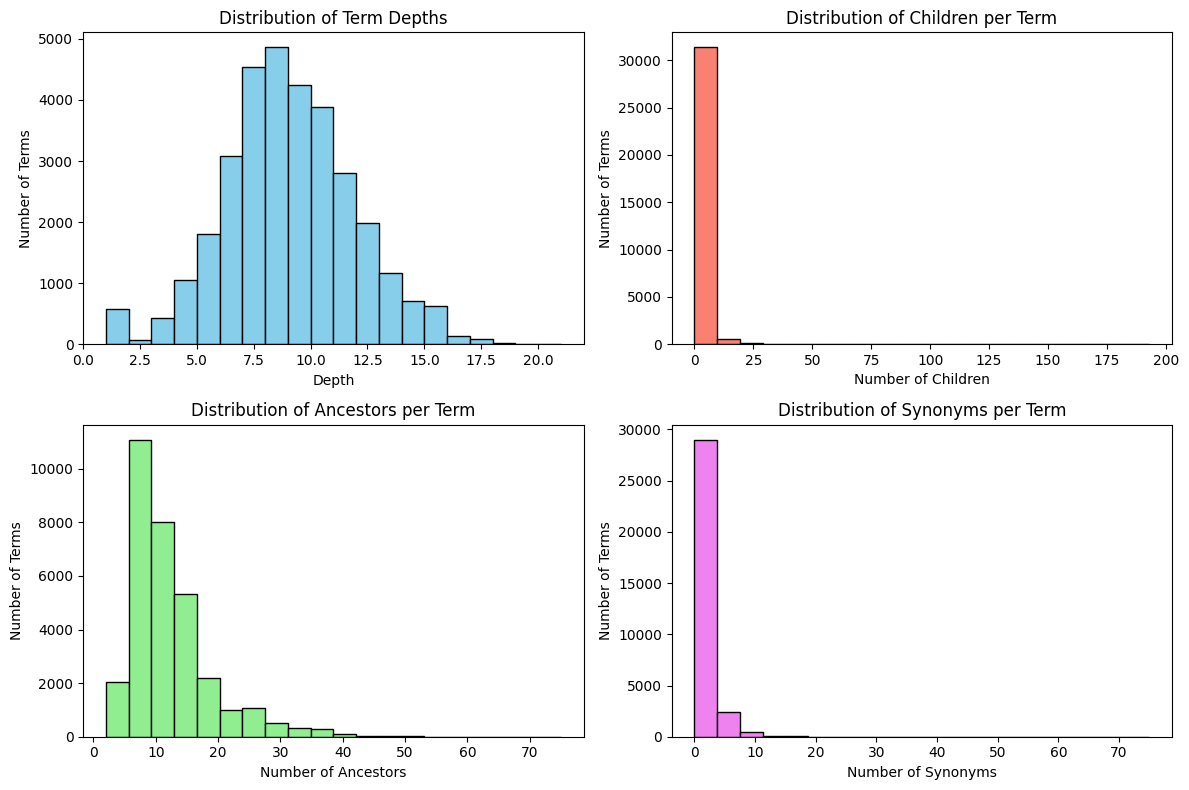

In [11]:
plt.figure(figsize=(12, 8))

plt.subplot(2,2,1)
plt.hist(depths, bins=20, color='skyblue', edgecolor='black')
plt.title("Distribution of Term Depths")
plt.xlabel("Depth")
plt.ylabel("Number of Terms")

plt.subplot(2,2,2)
plt.hist(children_counts, bins=20, color='salmon', edgecolor='black')
plt.title("Distribution of Children per Term")
plt.xlabel("Number of Children")
plt.ylabel("Number of Terms")

plt.subplot(2,2,3)
plt.hist(ancestor_counts, bins=20, color='lightgreen', edgecolor='black')
plt.title("Distribution of Ancestors per Term")
plt.xlabel("Number of Ancestors")
plt.ylabel("Number of Terms")

plt.subplot(2,2,4)
plt.hist(synonym_counts, bins=20, color='violet', edgecolor='black')
plt.title("Distribution of Synonyms per Term")
plt.xlabel("Number of Synonyms")
plt.ylabel("Number of Terms")

plt.tight_layout()
plt.show()

###  Branch Overview
Example: get terms under "Phenotypic abnormality"

In [12]:
phenotypic_root = hpo.search_one(label="Phenotypic abnormality")
if phenotypic_root:
    phenotypic_terms = list(phenotypic_root.subclasses())
    print(f"Number of terms under 'Phenotypic abnormality': {len(phenotypic_terms)}")

Number of terms under 'Phenotypic abnormality': 23


# 3. Printing HPO Terms
By label or id to get an more overview of how one term is represented

In [17]:
def print_hpo_term(term_identifier, ontology):
    """
    Prints a detailed overview of an HPO term.
    term_identifier: str, either HPO ID (HP:xxxxxxx) or label
    ontology: loaded OWLready2 ontology
    """
    # Search by ID first
    if term_identifier.startswith("HP:"):
        iri = f"http://purl.obolibrary.org/obo/{term_identifier.replace(':', '_')}"
        term = ontology.search_one(iri=iri)
    else:  # Search by label
        term = ontology.search_one(label=term_identifier)
    
    if not term:
        print(f"Term '{term_identifier}' not found in the ontology.")
        return
    
    print(f"\n--- HPO Term Overview ---")
    print(f"Name / ID: {term.name}")
    if term.label:
        print(f"Labels: {term.label}")
    if hasattr(term, "hasExactSynonym") and term.hasExactSynonym:
        print(f"Synonyms: {term.hasExactSynonym}")
    if hasattr(term, "definition") and term.definition:
        print(f"Definition: {term.definition}")
    
    # Parents (is_a)
    parents = [p.name for p in term.is_a if isinstance(p, ThingClass)]
    print(f"Parents (is_a): {parents if parents else 'None'}")
    
    # Children (subclasses)
    children = [c.name for c in term.subclasses()]
    print(f"Children (subclasses): {children if children else 'None'}")
    
    # Ancestors
    ancestors = [a.name for a in term.ancestors() if isinstance(a, ThingClass)]
    print(f"Ancestors: {ancestors if ancestors else 'None'}")
    
    # Optional: object properties
    for prop in ontology.object_properties():
        values = prop[term]
        if values:
            print(f"{prop.name}: {[v.name for v in values]}")
    print(f"---------------------------\n")

In [ ]:
# Assuming 'onto' is already loaded
print_hpo_term("HP:0001250", hpo)  # By ID
print_hpo_term("Seizure", hpo)     # By label


--- HPO Term Overview ---
Name / ID: HP_0001250
Labels: ['Seizure']
Synonyms: ['Epileptic seizure', 'Seizures']
Parents (is_a): ['HP_0012638']
Children (subclasses): ['HP_0002069', 'HP_0002197', 'HP_0011146', 'HP_0033259', 'HP_0002133', 'HP_0011145', 'HP_0007359', 'HP_0020219', 'HP_0020207', 'HP_0031951', 'HP_0032807', 'HP_0032892']
Ancestors: ['HP_0001250', 'HP_0000001', 'HP_0012638', 'Thing', 'HP_0000118', 'HP_0000707']
---------------------------


--- HPO Term Overview ---
Name / ID: HP_0001250
Labels: ['Seizure']
Synonyms: ['Epileptic seizure', 'Seizures']
Parents (is_a): ['HP_0012638']
Children (subclasses): ['HP_0002069', 'HP_0002197', 'HP_0011146', 'HP_0033259', 'HP_0002133', 'HP_0011145', 'HP_0007359', 'HP_0020219', 'HP_0020207', 'HP_0031951', 'HP_0032807', 'HP_0032892']
Ancestors: ['HP_0001250', 'HP_0000001', 'HP_0012638', 'Thing', 'HP_0000118', 'HP_0000707']
---------------------------



# 4. Graph Overview
HPO is a directed Acyclic Graph (DAG), which acts as a hierarchical, multi-parent structure representing the relationships between phenotypic abnormalities.

- Directed: Edges have a specific direction (usually "is-a" relationship)
- Acyclic: There are no loops.
- Nodes & Relationship: Nodes are HPO terms and edges define hierarchical relations
- Multi-Parenting: Unlike a strict tree, a single HPO term can have multiple parent terms.


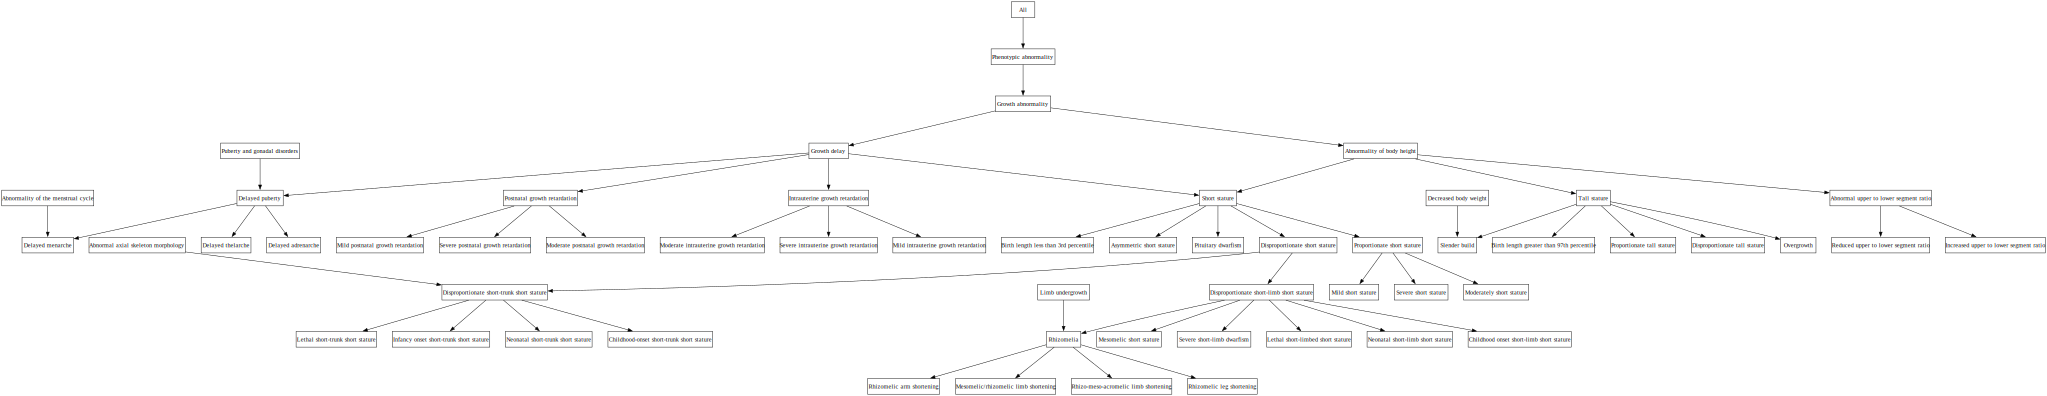

In [ ]:
# Select HPO root
root = hpo.search_one(iri="*HP_0000118")  # Phenotypic abnormality

# Create Graphviz Digraph
dot = Digraph(comment="HPO Phenotypic Abnormality Subtree",
              graph_attr={
                  "rankdir": "TB",
                  "splines": "true",
                  "nodesep": "0.5",
                  "ranksep": "1"
              })

# Recursive function to traverse ontology
def add_class_edges(cls, dot, visited=set(), max_nodes=200):
    if len(visited) >= max_nodes:
        return
    label = cls.label.first() if cls.label else cls.name
    if label in visited:
        return
    visited.add(label)
    dot.node(label, label, shape="box")
    for parent in cls.is_a:
        if isinstance(parent, ThingClass) and parent.name != "Thing":
            parent_label = parent.label.first() if parent.label else parent.name
            dot.node(parent_label, parent_label, shape="box")
            dot.edge(parent_label, label)
    for child in cls.subclasses():
        add_class_edges(child, dot, visited, max_nodes)

# Build graph
add_class_edges(root, dot, max_nodes=50)

display(dot)
# Render
# dot.render("hpo_graph_50", format="png", view=True)
# print("Graph saved as hpo_graph_50.png")